<a href="https://colab.research.google.com/github/nicolasspaniol/deep-learning-pa1/blob/main/notebooks/part0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import cv2
import numpy as np
import random
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [33]:
class SyntheticEllipseDataset(Dataset):
    def __init__(self, num_samples=500, img_size=128):
        self.num_samples = num_samples
        self.img_size = img_size

    def __len__(self):
        return self.num_samples

    def _generate_sample(self):
        size = self.img_size
        img = np.ones((size, size, 3), dtype=np.uint8) * 255
        mask = np.zeros((size, size), dtype=np.uint8)

        num_ellipses = random.randint(5, 20)
        for i in range(num_ellipses):
            center = (random.randint(10, size-10), random.randint(10, size-10))
            axes = (random.randint(5, 20), random.randint(5, 20))
            angle = random.randint(0, 180)
            gray = random.randint(30, 180)

            cv2.ellipse(img, center, axes, angle, 0, 360, (gray, gray, gray), -1)
            cv2.ellipse(mask, center, axes, angle, 0, 360, 255, -1)

        noise = np.random.normal(0, 15, img.shape)
        img = np.clip(img + noise, 0, 255).astype(np.uint8)

        return img, mask

    def __getitem__(self, idx):
        img, mask = self._generate_sample()

        img_t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        mask_t = torch.from_numpy(mask).float() / 255.0

        return img_t, mask_t

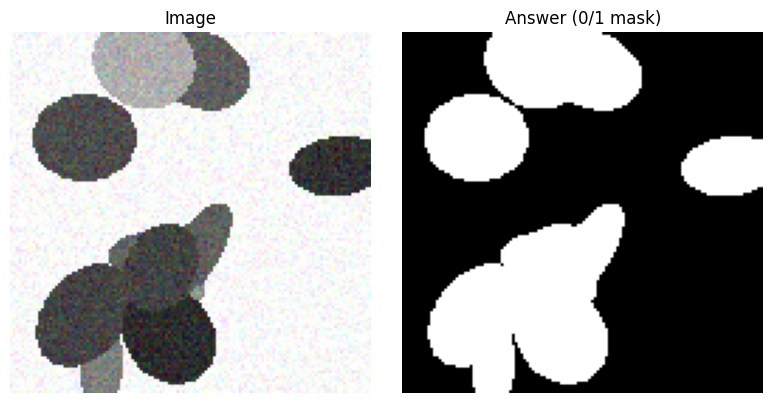

In [38]:
# Usage example

dataset = SyntheticEllipseDataset(num_samples=500)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

# Visualize a sample
img_t, mask_t = dataset[0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_t.permute(1, 2, 0).numpy())
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(mask_t.numpy(), cmap="gray")
axes[1].set_title("Answer (0/1 mask)")
axes[1].axis("off")

plt.tight_layout()
plt.show()